In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

DATA_PATH = "../data/processed/final.csv"

In [10]:
df = pd.read_csv(DATA_PATH)

df.head()

,director,cast,country,release_year,rating,duration,listed_in,year_added,month_added,type
0,-0.286672,-0.880537,0.840338,0.816465,-1.637677,0.421428,-0.011072,1.399662,0.694944,0
1,0.627426,-1.466496,-0.084435,0.988733,0.492567,-1.322388,1.060569,1.399662,0.694944,1
2,-0.444994,1.207564,0.840338,0.988733,0.492567,-1.342204,-0.256018,1.399662,0.694944,1
3,0.627426,-0.880537,0.840338,0.988733,0.492567,-1.342204,0.164983,1.399662,0.694944,1
4,0.627426,0.534847,-0.998759,0.988733,0.492567,-1.322388,0.899822,1.399662,0.694944,1


In [11]:
print("Shape:", df.shape)

df.info()

Shape: (8469, 10)
<class 'pandas.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   director      8469 non-null   float64
 1   cast          8469 non-null   float64
 2   country       8469 non-null   float64
 3   release_year  8469 non-null   float64
 4   rating        8469 non-null   float64
 5   duration      8469 non-null   float64
 6   listed_in     8469 non-null   float64
 7   year_added    8469 non-null   float64
 8   month_added   8469 non-null   float64
 9   type          8469 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 661.8 KB


In [12]:
missing = df.isnull().sum().sort_values(ascending=False)

missing

director        0
cast            0
country         0
release_year    0
rating          0
duration        0
listed_in       0
year_added      0
month_added     0
type            0
dtype: int64

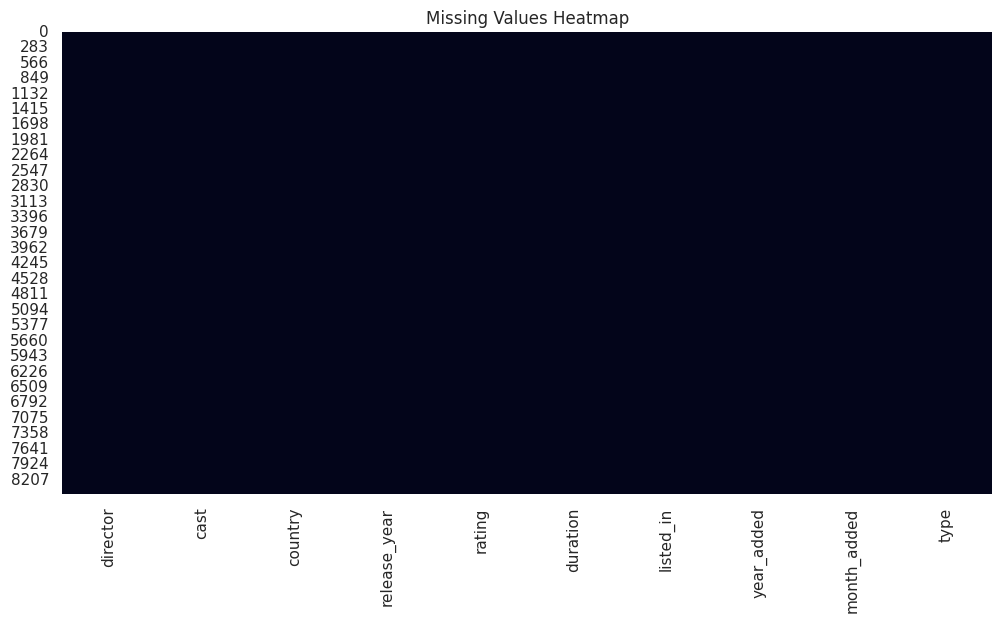

In [13]:
plt.figure(figsize=(12,6))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values Heatmap")

plt.show()

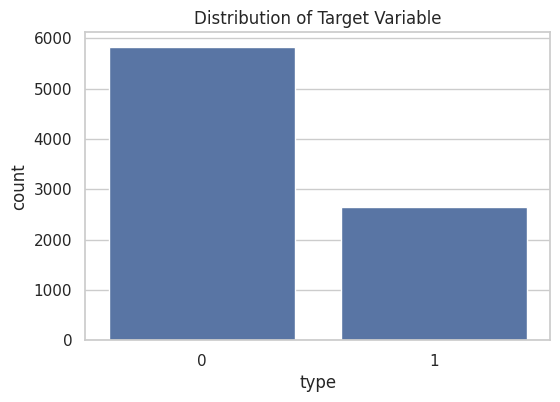

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="type")

plt.title("Distribution of Target Variable")

plt.show()

In [16]:
# Ensure duration is string first
df["duration_clean"] = df["duration"].astype(str).str.extract(r"(\d+)").astype(float)

df["duration_clean"].head()

0    0.0
1    1.0
2    1.0
3    1.0
4    1.0
Name: duration_clean, dtype: float64

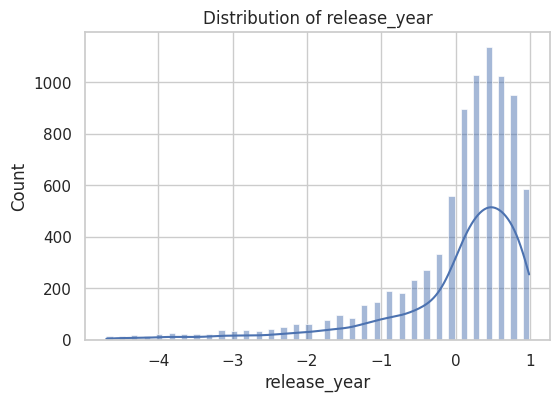

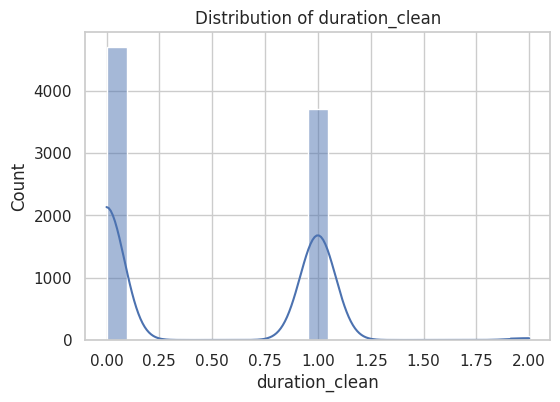

In [17]:
numeric_cols = ["release_year", "duration_clean"]

for col in numeric_cols:
    
    plt.figure(figsize=(6,4))
    
    sns.histplot(df[col], kde=True)
    
    plt.title(f"Distribution of {col}")
    
    plt.show()

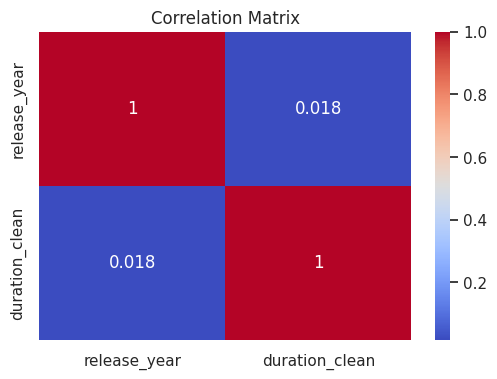

In [18]:
corr_df = df[["release_year", "duration_clean"]]

corr = corr_df.corr()

plt.figure(figsize=(6,4))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

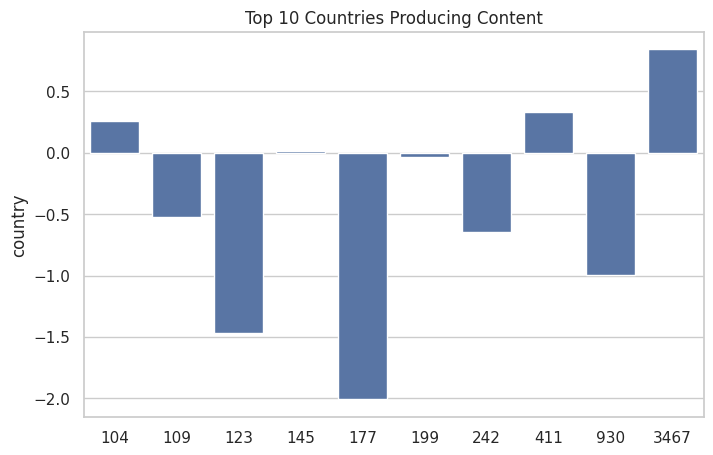

In [19]:
top_countries = df["country"].value_counts().head(10)

plt.figure(figsize=(8,5))

sns.barplot(x=top_countries.values, y=top_countries.index)

plt.title("Top 10 Countries Producing Content")

plt.show()